# Práctica: Un detector de bordes completo

En esta práctica vamos a desarrollar un detector completo de bordes que, partiendo de lo que hemos visto en clase, trate de obtener una imagen real de bordes con todas sus características. Para que un detector de bordes sea útil, debe cumplir las siguientes características:
- Mininimizar el número de falsos positivos
- Localizar los bordes de la forma más precisa posible
- Detectar un único píxel (de grosor) para cada borde

Para ello, vamos a tratar de implementar los siguientes pasos: 
- filtro de suavizado para la eliminación de ruido
- detección de bordes mediante el cálculo del gradiente
- supresión de no máximos
- umbralización y rellenado de huecos 

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

### Paso 1: filtro de suavizado para la eliminación de ruido

Implementa una función que reciba como parámetros una imagen y una máscara y realice la convolución de dicha imagen con la máscara. El algoritmo de detección de bordes deberá aplicar un filtro guassiano de dimensión establecida por el usuario. Puedes generar fácilmente una máscara de convolución gaussiana usando la función `cv2.getGaussianKernel` tal y como aparece en el siguiente código.

In [4]:
n = 11 #tamaño del filtro
sigma = 3 #desviación de la gaussiana
mask = cv2.getGaussianKernel(n, sigma)*cv2.getGaussianKernel(n, sigma).T
# print(mask)


In [2]:
def filtro_suavizado(imagen, mascara):
    n, m = mascara.shape
    imagen_borde = cv2.copyMakeBorder(imagen, n//2, n//2, m//2, m//2, cv2.BORDER_REPLICATE)
    imagen_f = np.zeros(imagen.shape)
    for i in range(imagen.shape[0]):
        for j in range(imagen.shape[1]):
            imagen_f[i, j] = np.sum(imagen_borde[i:i+n, j:j+m]*mascara)
            #en este caso i, j de imagen_borde es i+n//2, j+m//2 de imagen_f
    return imagen_f

In [5]:
imagen = cv2.imread('images/cebra.jpg', 0)
mask = cv2.getGaussianKernel(n, sigma)*cv2.getGaussianKernel(n, sigma).T
imagen_fil = filtro_suavizado(imagen, mask)


In [22]:
cv2.imshow('Imagen original',imagen)
cv2.imshow('Imagen suavizada',np.uint8(imagen_fil))
cv2.waitKey(0)
cv2.destroyAllWindows()

### Paso 2: detección de bordes mediante el cálculo del gradiente

Implementa una función que reciba como parámetro la imagen y devuelva una nueva imagen de magnitudes y orientaciones de gradiente. Para calcularlas, necesitarás calcular la derivada parcial en x y en y por cada píxel mediante las máscaras de convolución

m_g_x = [[-1, -2, -1], [0, 0, 0], [1, 2, 1]]
m_g_y = [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]

A partir de las dos imágenes obtenidas, obtén la imagen de magnitudes aplicando 

$$E(u,v)=\sqrt{I_x (u,v)^2+I_y (u,v)^2 }$$
y la imagen de orientaciones aplicando 

$$\Phi(u,v)=atan2(I_y (u,v),I_x (u,v))$$

Puedes utilizar las funciones np.arctan2 y np.rad2deg. Puedes utilizar la llamada a la función filtro_suavizado (ojo con devolver valores uint). Para obtener magnitudes y orientaciones no es necesario ningún bucle for!

In [6]:
def gradiente(imagen_fil):
    m_g_x = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    m_g_y = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    G_x = filtro_suavizado(imagen_fil, m_g_x)
    G_y = filtro_suavizado(imagen_fil, m_g_y)
    E = np.sqrt(G_x**2 + G_y**2)
    Phi = np.rad2deg(np.arctan2(G_y, G_x))
    return E, Phi

In [7]:
E, phi = gradiente(imagen)

In [15]:
print(E[:10, :10])
cv2.imshow('Magnitudes',np.float32(E/E.max()))
cv2.waitKey(0)
cv2.destroyAllWindows()

[[ 50.99019514  45.27692569  58.          45.65084884  35.35533906
   15.29705854  92.31467922 112.32987136  60.29925373  44.94441011]
 [101.27191121  88.20430828  85.42833254  75.43208866  77.83315489
   67.18630813  76.11832894 137.5572608  109.28860874  31.40063694]
 [ 40.          29.73213749  32.28002478  26.83281573  63.95310782
  107.33126292  79.24645102  58.25804665  72.24956747  44.72135955]
 [ 82.21921916  76.55063684  71.11961755  62.62587325  32.80243893
   64.14047084 100.80674581 108.01851693  43.17406629  38.83297568]
 [ 53.14132102  32.28002478  47.85394446  50.03998401   7.61577311
   23.02172887  47.70744177  55.6057551   51.4781507   29.42787794]
 [ 82.37718131  73.00684899  83.86894539  79.51100553  56.14267539
   42.54409477  25.49509757  33.37663854  55.56977596  46.32493929]
 [115.94826433  80.62257748  45.27692569  54.40588203  24.08318916
   42.80186912  10.77032961  18.43908891  60.41522987  65.37583651]
 [ 41.23105626  47.26520919   9.05538514  50.          

### Paso 3: supresión de no máximos

Para localizar los bordes de la manera más precisa posible, vamos a aplicar una supresión de no máximos sobre las magnitudes de los bordes. La supresión de no máximos va a hacer que mantengamos únicamente aquellos bordes cuya magnitud sea máxima a lo largo de la dirección del gradiente. 

Recuerda que los cambios de intensidad van ocurriendo, normalmente, de manera paulatina. Si analizamos, por ejemplo,. los píxeles de la línea roja, todos van a tener una magnitud diferente, pero el gradiente apunta aproximadamente en la misma dirección en todos ellos.

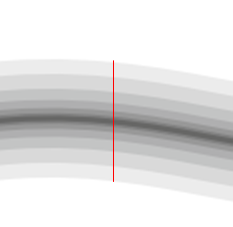

A lo largo de la dirección de dicho gradiente vamos a eliminar todos aquellos que no sean un máximo local.

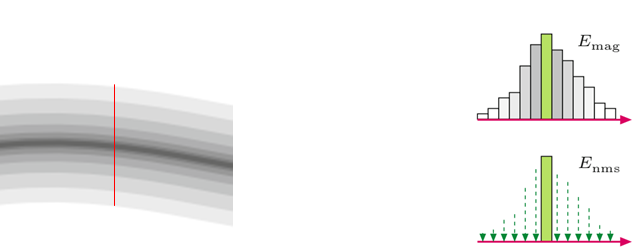

Sin embargo, no todo es tan sencillo como parece. El problema de la supresión de no máximos es la discontinuidad de los ángulos en $\Phi$, ya que existe mucha variación entre un píxel y sus vecinos. Para ello, necesitamos una forma de discretizar y simplificar las posibles direcciones de gradientes.

Para ello, vamos a utilizar una ruleta de gradientes. Básicamente, vamos a modificar el valor de $\Phi(u,v)$ por un valor discreto (1, 2, 3 o 4) en función de la siguiente ruleta:

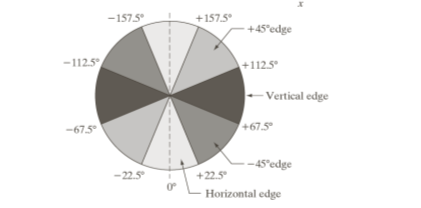

Por ejemplo, si asumimos que el 1 representa los gradientes verticales (bordes horizontales), entonces todos aquellos valores de $\Phi$ que valgan entre -22.5 y 22.5 o bien sean menores de -157.5 o bien sean mayores de 157.5 los modificaremos por el valor 1. 

Implementa la función ruleta de tal manera que devuelva una matriz del mismo tamaño que $\Phi$ pero con valores entre 1 y 4 siguiendo la ruleta. Puedes elegir qué representa el 2, el 3 o el 4, ya que es una representación que elegimos de manera arbitraria. 

In [36]:
def ruleta(phi):
    phi_d = np.zeros(phi.shape)
    phi_d[((phi >= -22.5) & (phi < 22.5)) | (phi >= 157.5) | (phi < -157.5)] = 1
    phi_d[((phi >= 22.5) & (phi < 67.5)) | ((phi >= -157.5) & (phi < -112.5))] = 2
    phi_d[((phi >= 67.5) & (phi < 112.5)) | ((phi >= -112.5) & (phi < -67.5))] = 3
    phi_d[((phi >= 112.5) & (phi < 157.5)) | ((phi >= -67.5) & (phi < -22.5))] = 4
    return phi_d

In [16]:
phi_d = ruleta(phi)
print(phi_d[:10, :10])

[[1. 1. 2. 2. 4. 0. 4. 4. 0. 3.]
 [1. 1. 2. 1. 4. 3. 0. 4. 4. 0.]
 [4. 4. 3. 2. 4. 4. 4. 2. 3. 4.]
 [0. 0. 4. 4. 2. 4. 1. 1. 1. 3.]
 [0. 0. 3. 3. 4. 4. 2. 4. 4. 3.]
 [1. 1. 2. 2. 1. 4. 2. 3. 4. 2.]
 [1. 4. 2. 3. 1. 4. 1. 1. 1. 1.]
 [2. 3. 3. 3. 3. 4. 3. 3. 2. 4.]
 [0. 0. 4. 3. 3. 4. 3. 4. 4. 2.]
 [4. 3. 3. 4. 4. 0. 3. 3. 4. 4.]]


In [14]:
cv2.imshow('Discretizados',phi_d/phi_d.max())
cv2.waitKey(0)
cv2.destroyAllWindows()

Una vez tengas los ángulos discretizados, toca aplicar la supresión de no máximos. Dada un píxel $(u,v)$, su magnitud $E(u,v)$ y la discretización de su angulo $\Phi_d(u,v)$, entonces:
- si $E(u,v)$ es mayor o igual que sus vecinos en la dirección del gradiente (discretizado), entonces $E_g(u,v)=E(u,v)$
- si no, $E_g(u,v)=0$

Así, por ejemplo, si $\Phi_d(u,v)=1$ (borde horizontal, gradiente vertical), entonces debemos comparar $E(u,v)$ con los píxeles vecinos en dicha dirección, es decir, $E(u-1,v)$ y $E(u+1,v)$. Si su valor es mayor o igual que el de los vecinos, entonces mantenemos su magnitud. Si no, la suprimimos, ya que no es un máximo en esa dirección.

In [17]:
def supresion_no_maximos(E, phi_d):
    E_g = np.zeros(E.shape)
    for i in range(1, E.shape[0]-1):
        for j in range(1, E.shape[1]-1):
            if phi_d[i, j] == 1:
                if (E[i, j] >= E[i, j-1]) and (E[i, j] >= E[i, j+1]):
                    E_g[i, j] = E[i, j]
            elif phi_d[i, j] == 2:
                if (E[i, j] >= E[i-1, j+1]) and (E[i, j] >= E[i+1, j-1]):
                    E_g[i, j] = E[i, j]
            elif phi_d[i, j] == 3:
                if (E[i, j] >= E[i-1, j]) and (E[i, j] >= E[i+1, j]):
                    E_g[i, j] = E[i, j]
            elif phi_d[i, j] == 4:
                if (E[i, j] >= E[i-1, j-1]) and (E[i, j] >= E[i+1, j+1]):
                    E_g[i, j] = E[i, j]
    return E_g
    

In [18]:
E_g = supresion_no_maximos(E, phi_d)

In [19]:
cv2.imshow('Magnitudes',E/E.max())
cv2.imshow('Magnitudes suprimidas',E_g/E_g.max())
cv2.waitKey(0)
cv2.destroyAllWindows()

### Paso 4: umbralización y rellenado de huecos

La detección final de contornos se realiza mediante una doble umbralización, seguida de un rellenado de huecos. La doble umbralización trata de de distinguir las magnitudes que han superado la supresión de no máximos en tres grupos:
- aquellas magnitudes que seguro acabarán siendo borde porque su valor es muy alto;
- aquellas que tienen un valor relativamente alto y podrían ser bordes;
- aquellas que tienen un valor bajo y no serán bordes. 

Para ello, debes calcular los umbrales $q_l$ y $q_h$ de manera que $q_l$ sea el el 10% del valor máximo de $E_g$ y $q_h$ sea el el 30% del valor máximo. Una vez calculados, devuelve dos nuevas matrices de la misma dimensión que $E_g$. La matriz $E_{nh}$ tendrá valores a 1 en aquellas posiciones de $E_g$ que sean mayores o iguales que $q_h$ (y cero en el resto). La matriz $E_{nl}$ tendrá valores a 1 en aquellas posiciones mayores o iguales que $q_l$ y menores que $q_h$. 




In [35]:
def umbralizacion(E_g):
    q_l = 0.1*E_g.max()
    q_h = 0.3*E_g.max()
    E_nh = np.zeros(E_g.shape)
    E_nl = np.zeros(E_g.shape)
    E_nh[E_g >= q_h] = 1
    E_nl[(E_g >= q_l) & (E_g < q_h)] = 1
    return E_nh, E_nl

In [21]:
E_nh, E_nl = umbralizacion(E_g)

In [22]:
cv2.imshow('E_nh',E_nh)
cv2.imshow('E_nl',E_nl)
cv2.waitKey(0)
cv2.destroyAllWindows()

Por último tocaría el rellenado de huecos, que consiste en ir complementando la matriz $E_{nh}$ con aquellos píxeles de $E_{nl}$ que estén lo suficientemente cerca de un píxel de $E_{nh}$. Para ello, vamos a hacer una aproximación iterativa:
- Empezamos visitando un píxel de $E_{nh}$, por ejemplo el $(u,v)$
- Marcaremos a 1 (en $E_{nh}$ todos aquellos píxeles vecinos de $(u,v)$ que en $E_{nl}$ tengan un valor a 1
- Visitamos el siguiente píxel de $E_{nh} y repetimos el proceso hasta visitar todos sus píxeles.

In [23]:
def rellenado(E_nh, E_nl):

    contornos = np.zeros((E_nh.shape[0]+2, E_nh.shape[1]+2))

    E_nh_amp = cv2.copyMakeBorder(E_nh, 1, 1, 1, 1, cv2.BORDER_CONSTANT, 0)
    E_nl_amp = cv2.copyMakeBorder(E_nl, 1, 1, 1, 1, cv2.BORDER_CONSTANT, 0)

    while np.sum(E_nh_amp) > 0:
        p = np.nonzero(E_nh_amp)
        x, y = p[0][0], p[1][0]
        contornos[x, y] = 1

        vecinos = E_nl_amp[x-1:x+2, y-1:y+2]        # débiles vecinos aún sin aceptar
        contornos[x-1:x+2, y-1:y+2] = np.logical_or(contornos[x-1:x+2, y-1:y+2], vecinos)
        E_nh_amp[x-1:x+2, y-1:y+2] = np.logical_or(E_nh_amp[x-1:x+2, y-1:y+2], vecinos)  # se visitarán después
        E_nl_amp[x-1:x+2, y-1:y+2] = 0              # ya aceptados: no se vuelven a añadir

        E_nh_amp[x, y] = 0

    return contornos[1:-1, 1:-1]

In [24]:
contornos = rellenado(E_nh, E_nl)

In [25]:
cv2.imshow('Contornos',contornos)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [26]:
E_nh.sum(), contornos.sum()

(np.float64(4153.0), np.float64(5152.0))

### Detector completo

Ahora, implementa el detector completo llamando a cada una de las funciones implementadas. Puedes probar con los siguientes parámetros:
- imagen: cebra
- tamaño del kernel de suavizado: n = 9
- desviación típica del filtro gaussiano: sigma = 1.5
- umbrales: q_l = 0.1 y q_h = 0.3

Para comprobar que lo vas haciendo correctamente, aquí tienes algunos valores aproximados que deberías ir obteniendo:
- E_g > 0: 38.858 píxeles
- E_nh.sum(): 9.798
- E_nl.sum(): 12.156
- contornos.sum(): 13.611

In [37]:
n = 9
sigma = 1.5

def detector(imagen, n):
    # Genera una máscara gaussiana y obtén la imagen filtrada
    mask = cv2.getGaussianKernel(n, sigma)*cv2.getGaussianKernel(n, sigma).T
    imagen_gausiana = filtro_suavizado(imagen, mask)
    # Genera las imágenes de magnitudes y orientaciones del gradiente
    E, phi = gradiente(imagen_gausiana)
    # Realiza la supresión de no máximos
    phi_d = ruleta(phi)
    E_g = supresion_no_maximos(E, phi_d)
    print("E_g > 0: ",np.count_nonzero(E_g))
    # Umbraliza y obtén la imagen final de contornos
    E_nh, E_nl = umbralizacion(E_g)
    print("E_nh.sum(): ",E_nh.sum())
    print("E_nl.sum(): ",E_nl.sum())
    contornos = rellenado(E_nh, E_nl)
    print("contornos.sum(): ",contornos.sum())
    return contornos

In [ ]:
imagen = cv2.imread('images/cebra.jpg', 0)
contornos = detector(imagen, n)
cv2.imshow('Original', imagen)
cv2.imshow('Contornos',contornos)
cv2.waitKey(0)
cv2.destroyAllWindows()

E_g > 0:  15286
E_nh.sum():  2913.0
E_nl.sum():  5497.0
contornos.sum():  3436.0
